In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..", ".."))  # go up two levels (from numerics to PauliSampling.jl)

  Activating project at `~/Desktop/PauliSampling.jl`


In [2]:
# # Ensure packages are installed
# for pkg in [
#     "PauliPropagation", "Plots", "LinearAlgebra", "ProgressMeter", "Distributions",
#     "Random", "Optimisers", "ReverseDiff", "MAT", "BenchmarkTools", "IterTools", "StatsBase", "LaTeXStrings", "Measures"
# ]
#     Pkg.add(pkg)
# end

In [2]:
# Load all packages
using PauliSampling, PauliPropagation, Plots, LinearAlgebra, ProgressMeter, Statistics, Printf, Distributions, Random, Optimisers, ReverseDiff, MAT, BenchmarkTools, IterTools, StatsBase, LaTeXStrings, Measures

## Target state

In [27]:
nq = 6 
target_wij_xyz = (0.0, 0.0, 0.346)
target_wi_xyz = (-0.822, 0.0, 0.0)
j_target = 1 .* target_wij_xyz
b_target = 1 .* target_wi_xyz
params_target = HamiltonianParams(nq; wi_xyz=b_target, wij_xyz=j_target)
target_tfim_paulis = makehamiltonian(params_target; connectivity=:nearest, periodic=false)
target_tfim_matrix = paulistringtomatrix(target_tfim_paulis);

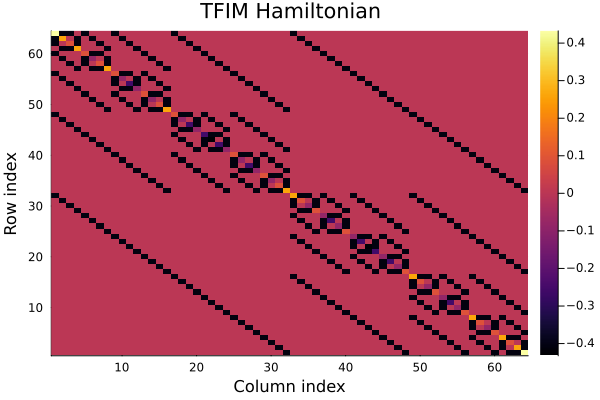

In [28]:
heatmap(reverse(real(target_tfim_matrix); dims=1),
        xlabel="Column index",
        ylabel="Row index",
        title="TFIM Hamiltonian"
        )

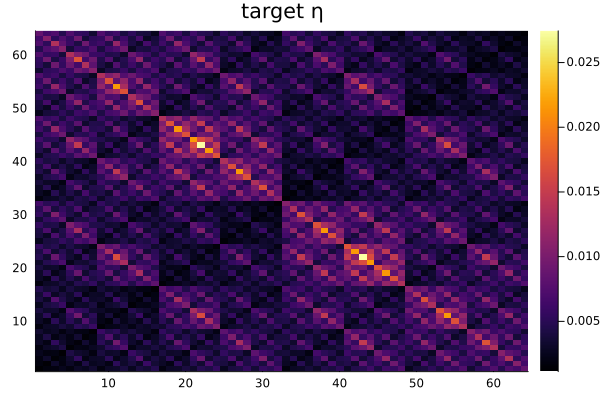

In [29]:
targert_circuit, θ = paulistringtocircuit(target_tfim_paulis)

num_layers = 100
target_beta = 2.
max_weight = nq
min_abs_coeff = 1e-20
target_eta = makethermalstate(nq, targert_circuit, θ, num_layers;
                                  beta=target_beta, max_weight=max_weight,
                                  min_abs_coeff=min_abs_coeff)
target_eta_matrix = paulistringtomatrix(target_eta)

heatmap(reverse(real(target_eta_matrix); dims=1), title="target η")

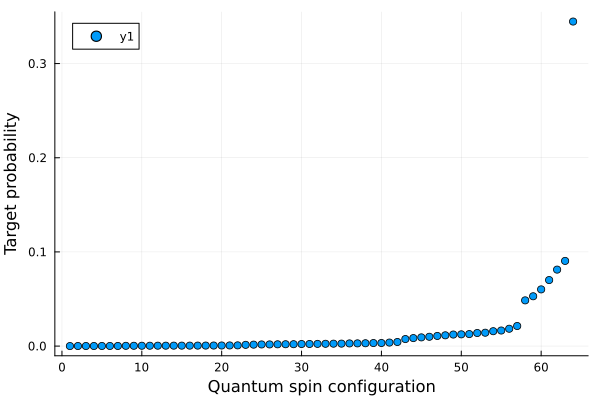

In [30]:
target_probs = computesymmetriceigenvalues(target_eta_matrix);
scatter(target_probs, ylabel="Target probability", xlabel="Quantum spin configuration")

## Model QBM

In [59]:
# parameters to learn. Set initial values at random
rng = MersenneTwister(1)
jz = randn(rng)
bx = randn(rng)
j = (0.0, 0.0, jz)
b = (-bx, 0.0, 0.0)
@printf("Spin interactions: %s\n", j)
@printf("Field values: %s\n", b)

Spin interactions: (0.0, 0.0, -0.13691541841944266)
Field values: (-0.9600615614130222, 0.0, 0.0)


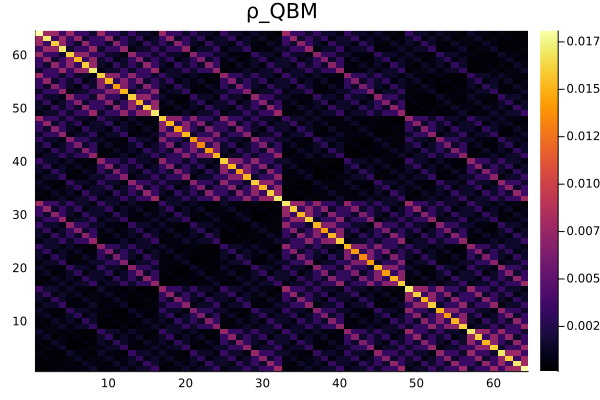

In [65]:
params = HamiltonianParams(nq; wi_xyz=b, wij_xyz=j)

qbm_tfim_paulis = makehamiltonian(params; connectivity=:nearest, periodic=false);
qbm_tfim_matrix = paulistringtomatrix(qbm_tfim_paulis)

circuit, params = paulistringtocircuit(qbm_tfim_paulis)

num_layers = 100
beta = 1.
max_weight = nq
min_abs_coeff = 1e-10
qbm = makethermalstate(nq, circuit, params, num_layers;
                                  beta=beta, max_weight=max_weight,
                                  min_abs_coeff=min_abs_coeff)
qbm_matrix = paulistringtomatrix(qbm)

heatmap(reverse(real(qbm_matrix); dims=1), title="ρ_QBM")

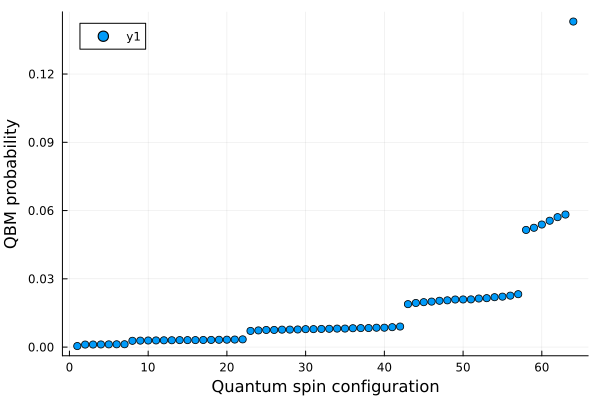

In [61]:
rho_probs = computesymmetriceigenvalues(qbm_matrix)
scatter(rho_probs, marker=:circle, ylabel="QBM probability", xlabel="Quantum spin configuration")

### Cost function: quantum relative entropy

$$S(\eta \| \rho_\theta) = \operatorname{Tr}[\eta \log \eta]-\operatorname{Tr}\left[\eta \log \rho_\theta\right]$$

In [62]:
computequantumrelativeentropy(target_eta_matrix, target_probs, qbm_tfim_matrix)

0.2802475057284006

### Gradient of quantum relative entropy

Given $H_\theta = \sum_i \theta_i H_i$ and the QBM $\rho_\theta = \frac{e^{-\beta H_\theta}}{\operatorname{Tr}[e^{-\beta H_\theta}]}$, the gradient of the cost function (quantum relative entropy) is given by

$$\partial_{\theta_i} S(\eta \| \rho_\theta) = \operatorname{Tr}[H_i \eta] -  \operatorname{Tr}[H_i \rho_\theta]$$

(see Eq. (8) in Tüysüz, Cenk, et al. "Learning to generate high-dimensional distributions with low-dimensional quantum Boltzmann machines." arXiv preprint arXiv:2410.16363 (2024))

In [79]:
grads = computegradients(params, target_eta, qbm)
println("Gradients: ", grads)

Gradients: HamiltonianParams(([0.11303725617437432, 0.11114445716200094, 0.11114059189061484, 0.11114059189066963, 0.11114445716214857, 0.11303725617462157], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]), ([0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0], [0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0], [0.0 -0.03670004835275805 0.0 0.0 0.0 0.0; -0.03670004835275805 0.0 -0.03674388111801681 0.0 0.0 0.0; 0.0 -0.03674388111801681 0.0 -0.03674396865543506 0.0 0.0; 0.0 0.0 -0.03674396865543506 0.0 -0.03674388111808872 0.0; 0.0 0.0 0.0 -0.03674388111808872 0.0 -0.03670004835277178; 0.0 0.0 0.0 0.0 -0.03670004835277178 0.0]))


# Training of the QBM 

In [ ]:
rng = MersenneTwister(1)
jz = randn(rng)
bx = randn(rng)
j = (0.0, 0.0, jz)
b = (-bx, 0.0, 0.0)
params = HamiltonianParams(nq; wi_xyz=b, wij_xyz=j)

# learning rate
gamma = 0.2
# number of epochs
epochs = 2000

# stop when gradient is smaller than epsilon, at the final number of epochs
epsilon = 1e-6
# keep track of loss and gradients
qre_hist = Float64[]
grad_hist = Vector{Float64}[]

for epoch in 1:epochs
    qbm_tfim_paulis = makehamiltonian(params; connectivity=:nearest, periodic=false);
    qbm_tfim_matrix = paulistringtomatrix(qbm_tfim_paulis)
    push!(qre_hist, computequantumrelativeentropy(target_eta_matrix, target_probs, qbm_tfim_matrix))

    # create qbm state
    circuit, theta = paulistringtocircuit(qbm_tfim_paulis)
    num_layers = 100
    beta = 1.
    max_weight = nq
    min_abs_coeff = 1e-10
    rho = makethermalstate(nq, circuit, theta, num_layers;
                                    beta=beta, max_weight=max_weight,
                                    min_abs_coeff=min_abs_coeff)
    rho_matrix = paulistringtomatrix(rho)

    # Compute and record gradient
    grads = computegradients(params, target_eta, rho)
    flat_grads = vcat(
        reduce(vcat, grads.wi_xyz)...,
        reduce(vcat, [vec(g) for g in grads.wij_xyz])...
    )
    push!(grad_hist, abs.(flat_grads))

    # Update parameters
    updateparameters!(params, grads, gamma)

    # Print diagnostics
    if epoch % 100 == 0
        @printf("\nEpoch %d\n", epoch)
        @printf("  Quantum relative entropy: %.6f\n", qre_hist[end])
        @printf("  Max abs gradient:         %.6f\n", maximum(grad_hist[end]))
    end

    # Stop if converged
    if maximum(grad_hist[end]) < epsilon
        println("Converged: max gradient < epsilon")
        break
    end
end


Epoch 100
  Quantum relative entropy: 0.013962
  Max abs gradient:         0.014907

Epoch 200
  Quantum relative entropy: 0.002496
  Max abs gradient:         0.006484

Epoch 300
  Quantum relative entropy: 0.000458
  Max abs gradient:         0.002820

Epoch 400
  Quantum relative entropy: 0.000081
  Max abs gradient:         0.001232

Epoch 500
  Quantum relative entropy: 0.000013
  Max abs gradient:         0.000541

Epoch 600
  Quantum relative entropy: 0.000002
  Max abs gradient:         0.000238

Epoch 700
  Quantum relative entropy: 0.000000
  Max abs gradient:         0.000105

Epoch 800
  Quantum relative entropy: 0.000001
  Max abs gradient:         0.000046

Epoch 900
  Quantum relative entropy: 0.000001
  Max abs gradient:         0.000020

Epoch 1000
  Quantum relative entropy: 0.000001
  Max abs gradient:         0.000009

Epoch 1100
  Quantum relative entropy: 0.000001
  Max abs gradient:         0.000004

Epoch 1200
  Quantum relative entropy: 0.000001
  Max abs grad

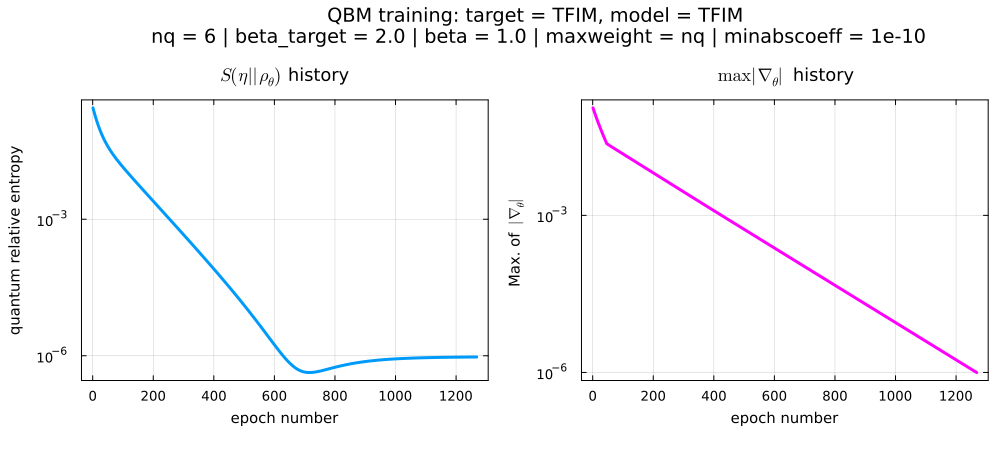

In [76]:
gr()

# ---- First plot ----
p1 = plot(qre_hist,
    yaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\!\eta || \!\rho\!_\theta\!\right)", " history"),
    legend = false,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm)

# ---- Second plot ----
p2 = plot([maximum(g) for g in grad_hist],
    yaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. of  " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),  
    legend = false,
    color = :fuchsia,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm)

# ---- Combine side by side ----
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training: target = TFIM, model = TFIM\n nq = 6 | beta_target = 2.0 | beta = 1.0 | maxweight = nq | minabscoeff = 1e-10",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm       
)

display(combined)

In [104]:
rng = MersenneTwister(1)
jz = randn(rng)
bx = randn(rng)
j = (0.0, 0.0, jz)
b = (-bx, 0.0, 0.0)
params = HamiltonianParams(nq; wi_xyz=b, wij_xyz=j)

# learning rate
gamma = 0.2
# number of epochs
epochs = 2000

# stop when gradient is smaller than epsilon, at the final number of epochs
epsilon = 1e-6
# keep track of loss and gradients
qre_hist = Float64[]
grad_hist = Vector{Float64}[]

for epoch in 1:epochs
    qbm_tfim_paulis = makehamiltonian(params; connectivity=:nearest, periodic=false);
    qbm_tfim_matrix = paulistringtomatrix(qbm_tfim_paulis)
    push!(qre_hist, computequantumrelativeentropy(target_eta_matrix, target_probs, qbm_tfim_matrix))

    # create qbm state
    circuit, theta = paulistringtocircuit(qbm_tfim_paulis)
    num_layers = 100
    beta = 1.2
    max_weight = nq
    min_abs_coeff = 1e-10
    rho = makethermalstate(nq, circuit, theta, num_layers;
                                    beta=beta, max_weight=max_weight,
                                    min_abs_coeff=min_abs_coeff)
    rho_matrix = paulistringtomatrix(rho)

    # Compute and record gradient
    grads = computegradients(params, target_eta, rho)
    flat_grads = vcat(
        reduce(vcat, grads.wi_xyz)...,
        reduce(vcat, [vec(g) for g in grads.wij_xyz])...
    )
    push!(grad_hist, abs.(flat_grads))

    # Update parameters
    updateparameters!(params, grads, gamma)

    # Print diagnostics
    if epoch % 100 == 0
        @printf("\nEpoch %d\n", epoch)
        @printf("  Quantum relative entropy: %.6f\n", qre_hist[end])
        @printf("  Max abs gradient:         %.6f\n", maximum(grad_hist[end]))
    end

    # Stop if converged
    if maximum(grad_hist[end]) < epsilon
        println("Converged: max gradient < epsilon")
        break
    end
end


Epoch 100
  Quantum relative entropy: 0.050026
  Max abs gradient:         0.013044

Epoch 200
  Quantum relative entropy: 0.036441
  Max abs gradient:         0.004774

Epoch 300
  Quantum relative entropy: 0.033607
  Max abs gradient:         0.001759

Epoch 400
  Quantum relative entropy: 0.032746
  Max abs gradient:         0.000654

Epoch 500
  Quantum relative entropy: 0.032448
  Max abs gradient:         0.000244

Epoch 600
  Quantum relative entropy: 0.032340
  Max abs gradient:         0.000091

Epoch 700
  Quantum relative entropy: 0.032301
  Max abs gradient:         0.000034

Epoch 800
  Quantum relative entropy: 0.032286
  Max abs gradient:         0.000013

Epoch 900
  Quantum relative entropy: 0.032280
  Max abs gradient:         0.000005

Epoch 1000
  Quantum relative entropy: 0.032278
  Max abs gradient:         0.000002
Converged: max gradient < epsilon


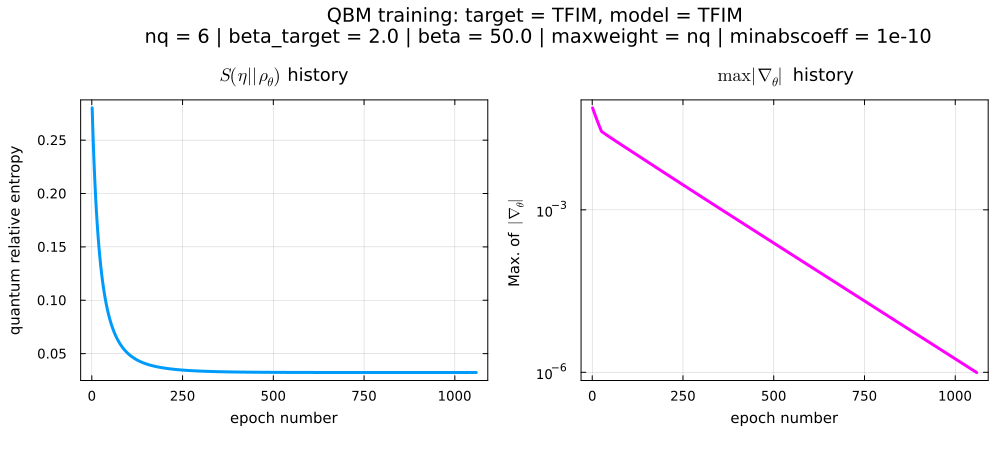

In [106]:
gr()

# ---- First plot ----
p1 = plot(qre_hist,
    # yaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\!\eta || \!\rho\!_\theta\!\right)", " history"),
    legend = false,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm)

# ---- Second plot ----
p2 = plot([maximum(g) for g in grad_hist],
    yaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. of  " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),  
    legend = false,
    color = :fuchsia,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm)

# ---- Combine side by side ----
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training: target = TFIM, model = TFIM\n nq = 6 | beta_target = 2.0 | beta = 50.0 | maxweight = nq | minabscoeff = 1e-10",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm       
)

display(combined)

## Compare the final parameters with the target parameters.

**Note** the Hamiltonian is the same but the target state was created with $\beta = 2 $ and we use a QBM with $\beta = -1$.

In [80]:
@printf("Original target parameters:\n Jz=%.6f Bx=%.6f\n", target_jz, target_bx)

Original target parameters:
 Jz=0.346000 Bx=0.822000


In [82]:
params

HamiltonianParams(([-1.6439986031344795, -1.6439971740698782, -1.6439971366518822, -1.6439971366512964, -1.6439971740710209, -1.6439986031370348], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]), ([0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [-0.13691541841944266 0.6919765242114472 … -0.13691541841944266 -0.13691541841944266; 0.6919765242114472 -0.13691541841944266 … -0.13691541841944266 -0.13691541841944266; … ; -0.13691541841944266 -0.13691541841944266 … -0.13691541841944266 0.6919765242440836; -0.13691541841944266 -0.13691541841944266 … 0.6919765242440836 -0.13691541841944266]))

In [26]:
qbm_jz, qbm_bx = (new_params[7] * target_beta, - new_params[1])
@printf("Trained QBM parameters:\n Jz=%.6f Bx=%.6f\n", qbm_jz, qbm_bx)

Trained QBM parameters:
 Jz=0.347141 Bx=0.822253


In [29]:
# percentage relative difference
@printf("Relative difference:\n Jz=%.2f%% Bx=%.2f%%\n",
        100*(abs(target_jz - qbm_jz))/target_jz,
        100*(abs(target_bx - qbm_bx))/target_bx)

Relative difference:
 Jz=0.33% Bx=0.03%


Compare the "images" of the target and trained QBM density matrices

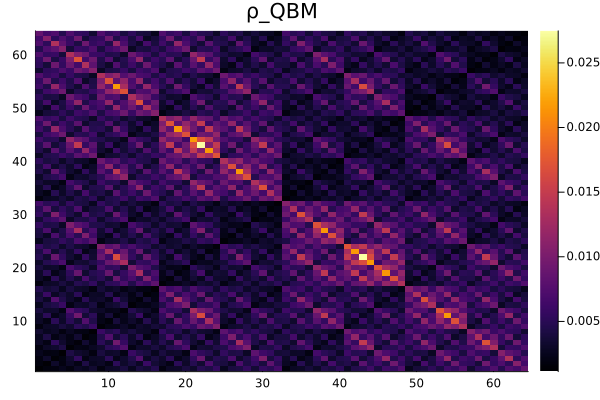

In [30]:
qbm_tfim_paulis = maketfim(nq, coeffs=new_params)
qbm_tfim_matrix = paulistringtomatrix(qbm_tfim_paulis)

circuit, params = paulistringtocircuit(qbm_tfim_paulis)

num_layers = 100
beta = 1.
max_weight = nq
min_abs_coeff = 1e-10
qbm = makethermalstate(nq, circuit, params, num_layers;
                                  beta=beta, max_weight=max_weight,
                                  min_abs_coeff=min_abs_coeff)
qbm_matrix = paulistringtomatrix(qbm)

heatmap(reverse(real(qbm_matrix); dims=1), title="ρ_QBM")

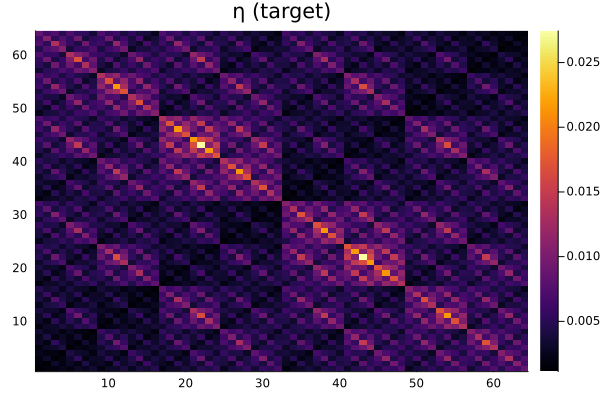

In [31]:
heatmap(reverse(real(target_eta_matrix); dims=1), title="η (target)")

A way to compare the two density matrices is to compute the fidelity between them. A fidelity close to 1 means the two quantum states are the same

In [34]:
# Uhlmann fidelity (squared) between density matrices
function fidelity(ρ::AbstractMatrix, σ::AbstractMatrix)
    F = 0.0
    # sqrt(ρ)
    evals, evecs = eigen(Hermitian(ρ))
    sqrtρ = evecs * Diagonal(sqrt.(clamp.(evals, 0, Inf))) * evecs'
    A = sqrtρ * σ * sqrtρ
    evalsA = computesymmetriceigenvalues(A)
    rootF = sum(sqrt.(clamp.(evalsA, 0, Inf)))
    (rootF)^2
end

fidelity (generic function with 1 method)

In [35]:
# fidelity
F = fidelity(target_eta_matrix, qbm_matrix)
F

0.9999998044939602

We can also plot the probability distributions:

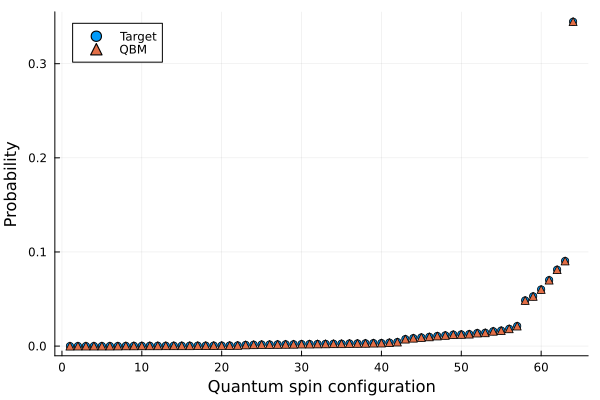

In [36]:
rho_probs = computesymmetriceigenvalues(qbm_matrix)
scatter(1:length(rho_probs), target_probs, label="Target", marker=:circle, xlabel="Quantum spin configuration", ylabel="Probability")
scatter!(1:length(rho_probs), rho_probs, label="QBM", marker=:utriangle)